In [124]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [125]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')

--2024-07-04 18:10:32--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 104.26.2.33, 104.26.3.33, 172.67.70.149, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|104.26.2.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv.7’

insurance.csv.7     100%[===================>]  49.09K  --.-KB/s    in 0.01s   

2024-07-04 18:10:32 (4.47 MB/s) - ‘insurance.csv.7’ saved [50264/50264]



In [126]:
dataset['sex'].replace(['male', 'female'], [0, 1], inplace =True)
dataset['smoker'].replace(['no', 'yes'], [0, 1], inplace =True)
dataset['region'].replace(['southwest', 'southeast', 'northwest', 'northeast'],[0,1,2,3], inplace=True)
dataset

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1,0,16884.92
1,18,0,33.8,1,0,1,1725.55
2,28,0,33.0,3,0,1,4449.46
3,33,0,22.7,0,0,2,21984.47
4,32,0,28.9,0,0,2,3866.86
...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,2,10600.55
1334,18,1,31.9,0,0,3,2205.98
1335,18,1,36.9,0,0,1,1629.83
1336,21,1,25.8,0,0,0,2007.95


In [127]:
from sklearn.model_selection import train_test_split
x = dataset.iloc[:, :]
y = dataset.iloc[:, :]
train_dataset, test_dataset, _, _ = train_test_split(x,y,test_size=0.2,random_state=0)
train_dataset

,age,sex,bmi,children,smoker,region,expenses
621,37,0,34.1,4,1,0,40182.25
194,18,0,34.4,0,0,1,1137.47
240,23,1,36.7,2,1,3,38511.63
1168,32,0,35.2,2,0,0,4670.64
1192,58,1,32.4,1,0,3,13019.16
...,...,...,...,...,...,...,...
763,27,0,26.0,0,0,3,3070.81
835,42,0,36.0,2,0,1,7160.33
1216,40,0,25.1,0,0,1,5415.66
559,19,0,35.5,0,0,2,1646.43


In [128]:
train_labels = train_dataset.pop('expenses')
test_labels = test_dataset.pop('expenses')

In [129]:
model = keras.Sequential()
model.add(layers.Dense(128, activation='relu', input_shape=(train_dataset.shape[1],)))
model.add(layers.Dense(64))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1))
model.compile(optimizer= tf.optimizers.Adam(learning_rate=0.1), loss='mae', metrics=['mae','mse'])
model.summary()

Model: "sequential_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_64 (Dense)            (None, 128)               896       
                                                                 
 dense_65 (Dense)            (None, 64)                8256      
                                                                 
 dense_66 (Dense)            (None, 32)                2080      
                                                                 
 dropout_15 (Dropout)        (None, 32)                0         
                                                                 
 dense_67 (Dense)            (None, 1)                 33        
                                                                 
Total params: 11265 (44.00 KB)
Trainable params: 11265 (44.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [130]:
hist = model.fit(train_dataset, train_labels, epochs=100, validation_split=0.5, verbose=0)

9/9 - 0s - loss: 3023.5088 - mae: 3023.5088 - mse: 33452590.0000 - 36ms/epoch - 4ms/step
Testing set Mean Abs Error: 3023.51 expenses
You passed the challenge. Great job!
9/9 [==============================] - 0s 2ms/step


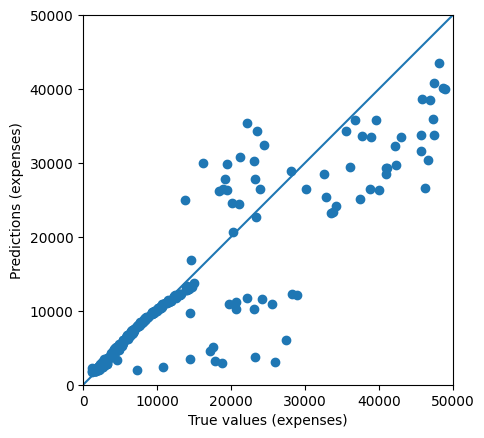

In [131]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)
